# EDA - Smard data

In this notebook, we inspect the data from smard.de website. It provides data for the actual electricity consumption, actual electricity generation and the day ahead price. We look at the hourly data from 12:00 AM, May 1, 2019 to 5:00 AM, May 1, 2026

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Day-ahead price data
Price : Euro/MWh

In [2]:
with open("Day_ahead_prices_201905010000_202605010600_Hour.csv", "r") as f:
    for i, line in enumerate(f, start=1):
        if i in [25664, 25665, 25666]:
            print(i, repr(line))

25664 'Apr 4, 2022 6:00 AM;Apr 4, 2022 7:00 AM;133.00;196.93;220.47;133.00;109.96;410.13;164.14;169.57;193.19;113.07;109.96;352.77;190.00;-;410.13;193.19;317.04\n'
25665 'Apr 4, 2022 7:00 AM;Apr 4, 2022 8:00 AM;120.60;435.19;202.50;120.60;120.60;2,712.99;200.00;178.26;429.43;120.60;120.60;391.50;190.00;-;450.00;429.43;429.43\n'
25666 'Apr 4, 2022 8:00 AM;Apr 4, 2022 9:00 AM;101.16;470.75;230.00;101.16;101.16;2,987.78;254.60;178.65;450.05;101.16;101.16;437.55;235.00;-;470.00;450.05;450.05\n'


We note that the data is separated by semicolon in this csv file

In [3]:
df_day_ahead = pd.read_csv("Day_ahead_prices_201905010000_202605010600_Hour.csv",sep=";")

/var/folders/mj/j1l9s_3x10gcl1hrm1v5zb140000gn/T/ipykernel_35877/113238514.py:1: DtypeWarning: Columns (0: ∅ DE/LU neighbours [€/MWh] Calculated resolutions, 1: France [€/MWh] Calculated resolutions, 2: Poland [€/MWh] Calculated resolutions, 3: Slovenia [€/MWh] Calculated resolutions, 4: Hungary [€/MWh] Calculated resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df_day_ahead = pd.read_csv("Day_ahead_prices_201905010000_202605010600_Hour.csv",sep=";")


In [4]:
df_day_ahead.shape

(61374, 19)

In [6]:
df_day_ahead.head()

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"May 1, 2019 12:00 AM","May 1, 2019 1:00 AM",38.00,-,38.00,38.00,38.00,38.00,38.00,37.98,38.00,-,3.10,35.63,35.38,-,51.40,38.0,35.38
1,"May 1, 2019 1:00 AM","May 1, 2019 2:00 AM",35.20,-,35.20,35.20,35.20,35.20,35.20,35.21,35.20,-,4.84,33.27,32.52,-,55.00,35.2,32.52
2,"May 1, 2019 2:00 AM","May 1, 2019 3:00 AM",32.64,-,32.64,32.64,32.64,32.64,32.64,32.64,32.64,-,4.09,32.32,31.00,-,49.65,32.64,31.00
3,"May 1, 2019 3:00 AM","May 1, 2019 4:00 AM",31.16,-,31.16,31.16,31.16,31.16,31.16,31.16,31.16,-,4.26,31.41,30.00,-,47.17,31.16,30.00
4,"May 1, 2019 4:00 AM","May 1, 2019 5:00 AM",29.56,-,26.51,29.56,29.56,26.51,33.30,31.23,28.77,-,3.92,31.13,30.00,-,44.32,28.77,30.00


In [7]:
df_day_ahead[df_day_ahead['Germany/Luxembourg [€/MWh] Calculated resolutions']<0]

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
14,"May 1, 2019 2:00 PM","May 1, 2019 3:00 PM",-2.46,-,30.28,-2.46,-2.46,14.62,48.27,38.29,-2.46,-,12.90,8.55,7.96,-,21.87,-2.46,7.96
15,"May 1, 2019 3:00 PM","May 1, 2019 4:00 PM",-2.82,-,11.97,-2.82,-2.82,7.18,42.16,38.22,0.86,-,10.40,8.08,7.51,-,29.45,0.86,7.51
277,"May 12, 2019 1:00 PM","May 12, 2019 2:00 PM",-0.51,-,13.11,-0.51,-0.51,8.36,37.40,42.01,0.03,-,1.97,0.44,15.76,-,40.61,40.0,15.76
278,"May 12, 2019 2:00 PM","May 12, 2019 3:00 PM",-15.06,-,-1.22,-15.06,-15.06,-5.16,35.00,41.94,-10.88,-,1.70,-6.77,15.36,-,39.15,39.15,15.36
279,"May 12, 2019 3:00 PM","May 12, 2019 4:00 PM",-22.96,-,-8.39,-19.93,-19.93,-12.27,34.90,41.76,-18.35,-,1.46,-10.93,15.03,-,38.00,38.0,15.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61356,"Apr 30, 2026 12:00 PM","Apr 30, 2026 1:00 PM",-16.25,-4.92,-13.59,-1.98,2.41,-13.5,-16.70,34.47,-4.86,0.0,2.71,-29.59,-13.47,-,48.46,-9.32,-12.22
61357,"Apr 30, 2026 1:00 PM","Apr 30, 2026 2:00 PM",-32.02,-16.09,-31.25,-13.90,4.23,-30.61,-31.55,11.94,-18.95,0.0,4.44,-43.75,-27.55,-,29.57,-23.43,-28.24
61358,"Apr 30, 2026 2:00 PM","Apr 30, 2026 3:00 PM",-28.93,-13.13,-27.33,-16.00,0.89,-25.86,-27.99,22.53,-10.86,0.0,1.27,-40.03,-21.05,-,47.96,0.94,-14.53
61359,"Apr 30, 2026 3:00 PM","Apr 30, 2026 4:00 PM",-12.05,-4.88,-11.31,-9.27,2.27,-10.58,-11.64,21.07,-4.77,-6.98,2.64,-16.99,-8.08,-,31.88,5.25,-0.43


Thus, we see that there are 2106 incidences of negative day ahead price within the timeframe of the data across all regions.

In [8]:
df_day_ahead.columns

Index(['Start date', 'End date',
       'Germany/Luxembourg [€/MWh] Calculated resolutions',
       '∅ DE/LU neighbours [€/MWh] Calculated resolutions',
       'Belgium [€/MWh] Calculated resolutions',
       'Denmark 1 [€/MWh] Calculated resolutions',
       'Denmark 2 [€/MWh] Calculated resolutions',
       'France [€/MWh] Calculated resolutions',
       'Netherlands [€/MWh] Calculated resolutions',
       'Norway 2 [€/MWh] Calculated resolutions',
       'Austria [€/MWh] Calculated resolutions',
       'Poland [€/MWh] Calculated resolutions',
       'Sweden 4 [€/MWh] Calculated resolutions',
       'Switzerland [€/MWh] Calculated resolutions',
       'Czech Republic [€/MWh] Calculated resolutions',
       'DE/AT/LU [€/MWh] Calculated resolutions',
       'Northern Italy [€/MWh] Calculated resolutions',
       'Slovenia [€/MWh] Calculated resolutions',
       'Hungary [€/MWh] Calculated resolutions'],
      dtype='str')

In [9]:
df_day_ahead.dtypes

Start date                                               str
End date                                                 str
Germany/Luxembourg [€/MWh] Calculated resolutions    float64
∅ DE/LU neighbours [€/MWh] Calculated resolutions     object
Belgium [€/MWh] Calculated resolutions               float64
Denmark 1 [€/MWh] Calculated resolutions             float64
Denmark 2 [€/MWh] Calculated resolutions             float64
France [€/MWh] Calculated resolutions                 object
Netherlands [€/MWh] Calculated resolutions           float64
Norway 2 [€/MWh] Calculated resolutions              float64
Austria [€/MWh] Calculated resolutions               float64
Poland [€/MWh] Calculated resolutions                 object
Sweden 4 [€/MWh] Calculated resolutions              float64
Switzerland [€/MWh] Calculated resolutions           float64
Czech Republic [€/MWh] Calculated resolutions        float64
DE/AT/LU [€/MWh] Calculated resolutions                  str
Northern Italy [€/MWh] C

We will be looking at the day-ahead price only for Germany/Luxembourg

In [10]:
cols_keep_day_ahead = ["Start date", "Germany/Luxembourg [€/MWh] Calculated resolutions"]

In [11]:
df_day_ahead = df_day_ahead[cols_keep_day_ahead]

In [12]:
df_day_ahead = df_day_ahead.rename(columns={"Germany/Luxembourg [€/MWh] Calculated resolutions" : "Price", "Start date" : "Start_date"})

In [13]:
df_day_ahead.head()

,Start_date,Price
0,"May 1, 2019 12:00 AM",38.00
1,"May 1, 2019 1:00 AM",35.20
2,"May 1, 2019 2:00 AM",32.64
3,"May 1, 2019 3:00 AM",31.16
4,"May 1, 2019 4:00 AM",29.56


In [14]:
# Converting "Start_date" which is str to datetime

df_day_ahead['Start_date'] = pd.to_datetime(df_day_ahead['Start_date'],format='%b %d, %Y %I:%M %p')

In [15]:
df_day_ahead['Start_date'].sample(10)

29839   2022-09-25 07:00:00
27592   2022-06-23 16:00:00
31037   2022-11-14 04:00:00
24607   2022-02-19 06:00:00
48595   2024-11-14 18:00:00
22134   2021-11-08 05:00:00
45372   2024-07-03 12:00:00
49236   2024-12-11 11:00:00
44089   2024-05-11 01:00:00
55712   2025-09-07 08:00:00
Name: Start_date, dtype: datetime64[us]

In [16]:
df_day_ahead['Negative_price'] = (df_day_ahead['Price']<0).astype(int)

In [17]:
df_day_ahead['Negative_price']

0        0
1        0
2        0
3        0
4        0
        ..
61369    0
61370    0
61371    0
61372    0
61373    0
Name: Negative_price, Length: 61374, dtype: int64

In [18]:
df_day_ahead['Price'].isna().sum()

np.int64(0)

In [19]:
print((df_day_ahead['Price']<0).value_counts(normalize=True))

Price
False    0.965686
True     0.034314
Name: proportion, dtype: float64


We see that around 3 percent of prices in the full dataset is negative.

Text(0.5, 1.0, 'Day-ahead price')

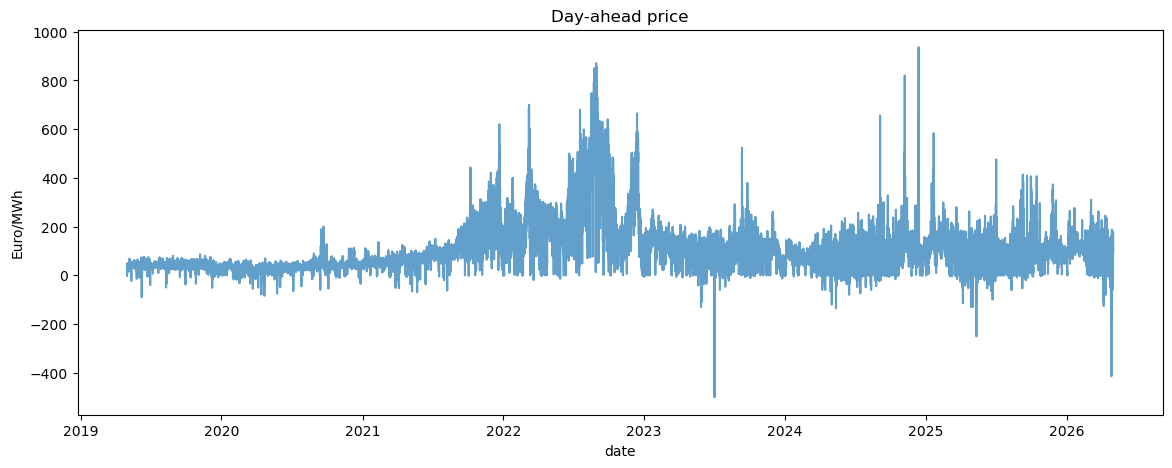

In [20]:
# Plotting the full time series
neg = df_day_ahead[df_day_ahead['Price']<0]

fig = plt.figure(figsize=(14,5))
plt.plot(df_day_ahead['Start_date'],df_day_ahead.Price,alpha=0.7)
plt.ylabel("Euro/MWh")
plt.xlabel("date")
plt.title("Day-ahead price")

Text(0.5, 1.0, 'Negative price hours by year')

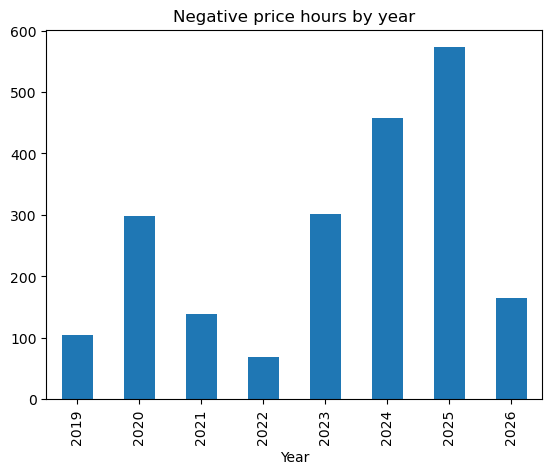

In [26]:
# Incidences of negative prices in each year

neg_yearly = (df_day_ahead['Price'].lt(0).groupby(df_day_ahead['Start_date'].dt.year)).sum()
neg_yearly.plot(kind='bar')
plt.xlabel("Year")
plt.title('Negative price hours by year')


Text(0.5, 1.0, 'Proportion of negative prices by month')

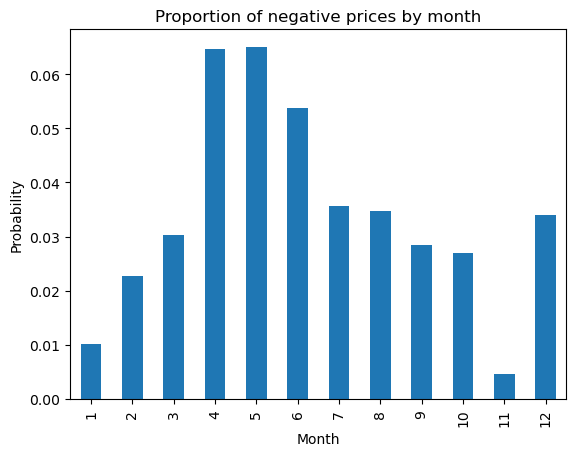

In [24]:
# Incidences of negative prices by month

neg_monthly = (df_day_ahead['Price'].lt(0).groupby(df_day_ahead['Start_date'].dt.month)).mean()
neg_monthly.plot(kind='bar')
plt.xlabel("Month")
plt.ylabel("Probability")
plt.title('Proportion of negative prices by month')


Text(0.5, 1.0, 'Proportion of negative prices by hour')

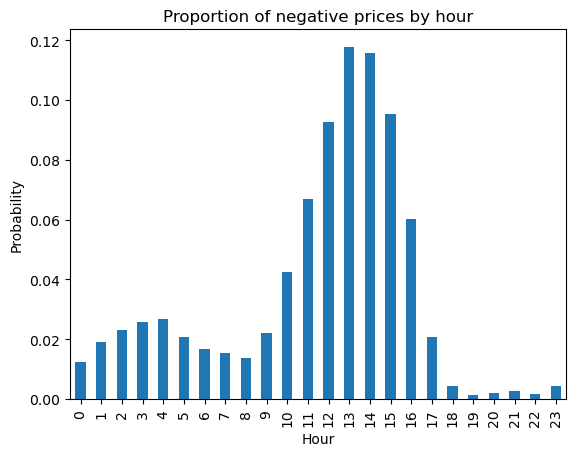

In [25]:
# Incidences of negative prices by hour

neg_monthly = (df_day_ahead['Price'].lt(0).groupby(df_day_ahead['Start_date'].dt.hour)).mean()
neg_monthly.plot(kind='bar')
plt.xlabel("Hour")
plt.ylabel("Probability")
plt.title('Proportion of negative prices by hour')


We note that most incidences of negative day ahead prices occur in the noon

## Actual electricity generation data

In [27]:
df_act_gen = pd.read_csv("Actual_generation_201905010000_202605010600_Hour.csv",sep=";")

In [28]:
df_act_gen.shape

(61374, 14)

In [29]:
df_act_gen.head()

,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
0,"May 1, 2019 12:00 AM","May 1, 2019 1:00 AM","4,608.75","2,123.75","1,222.25","6,336.00",0.00,171.50,"6,630.50","11,257.00","3,311.75","3,936.25","1,248.25","1,470.50"
1,"May 1, 2019 1:00 AM","May 1, 2019 2:00 AM","4,590.25","2,120.50","1,168.75","5,916.50",0.00,174.25,"6,626.50","11,035.00","2,850.25","3,594.50","1,093.50","1,478.50"
2,"May 1, 2019 2:00 AM","May 1, 2019 3:00 AM","4,597.75","2,052.00","1,386.00","5,750.00",0.00,178.25,"6,634.25","11,090.50","2,604.50","3,557.00",460.25,"1,490.25"
3,"May 1, 2019 3:00 AM","May 1, 2019 4:00 AM","4,593.50","2,086.75","1,502.75","6,128.50",0.00,179.25,"6,637.25","11,082.50","2,524.00","3,207.75",125.75,"1,483.25"
4,"May 1, 2019 4:00 AM","May 1, 2019 5:00 AM","4,592.75","2,118.50","1,671.50","6,520.50",0.00,181.00,"6,638.00","10,267.25","2,507.50","3,109.25",178.75,"1,495.75"


In [30]:
df_act_gen.columns

Index(['Start date', 'End date', 'Biomass [MWh] Calculated resolutions',
       'Hydropower [MWh] Calculated resolutions',
       'Wind offshore [MWh] Calculated resolutions',
       'Wind onshore [MWh] Calculated resolutions',
       'Photovoltaics [MWh] Calculated resolutions',
       'Other renewable [MWh] Calculated resolutions',
       'Nuclear [MWh] Calculated resolutions',
       'Lignite [MWh] Calculated resolutions',
       'Hard coal [MWh] Calculated resolutions',
       'Fossil gas [MWh] Calculated resolutions',
       'Hydro pumped storage [MWh] Calculated resolutions',
       'Other conventional [MWh] Calculated resolutions'],
      dtype='str')

In [31]:
cols_keep_act_gen = ['Start date', 'Biomass [MWh] Calculated resolutions',
       'Hydropower [MWh] Calculated resolutions',
       'Wind offshore [MWh] Calculated resolutions',
       'Wind onshore [MWh] Calculated resolutions',
       'Photovoltaics [MWh] Calculated resolutions',
       'Other renewable [MWh] Calculated resolutions',
       'Nuclear [MWh] Calculated resolutions',
       'Lignite [MWh] Calculated resolutions',
       'Hard coal [MWh] Calculated resolutions',
       'Fossil gas [MWh] Calculated resolutions',
       'Hydro pumped storage [MWh] Calculated resolutions',
       'Other conventional [MWh] Calculated resolutions']

df_act_gen = df_act_gen[cols_keep_act_gen]

In [32]:
df_act_gen = df_act_gen.rename(columns={'Start date': 'Start_date', 'Biomass [MWh] Calculated resolutions':'Biomass',
       'Hydropower [MWh] Calculated resolutions':'Hydro',
       'Wind offshore [MWh] Calculated resolutions':'Wind_offshore',
       'Wind onshore [MWh] Calculated resolutions':'Wind_onshore',
       'Photovoltaics [MWh] Calculated resolutions':'Photovolt',
       'Other renewable [MWh] Calculated resolutions':'Other_ren',
       'Nuclear [MWh] Calculated resolutions':'Nuclear',
       'Lignite [MWh] Calculated resolutions':'Lignite',
       'Hard coal [MWh] Calculated resolutions':'Hard_coal',
       'Fossil gas [MWh] Calculated resolutions':'Fossil_gas',
       'Hydro pumped storage [MWh] Calculated resolutions':'Hydro_pump_stor',
       'Other conventional [MWh] Calculated resolutions':'Other_conv'})

In [33]:
df_act_gen.columns

Index(['Start_date', 'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt', 'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv'],
      dtype='str')

In [34]:
renewable_cols = ['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt', 'Other_ren']

df_act_gen['Start_date'] = pd.to_datetime(df_act_gen['Start_date'],format='%b %d, %Y %I:%M %p')

IMPORTANT (note to self): In the last line of the code, make sure to use  df_act_gen['Start_date] = so that only the specific column is converted to datetime Series and not the entire dataframe is converted (that is do not write df_act_gen = ... )

In [35]:
df_act_gen.isna().sum()

Start_date         0
Biomass            0
Hydro              0
Wind_offshore      0
Wind_onshore       0
Photovolt          0
Other_ren          0
Nuclear            0
Lignite            0
Hard_coal          0
Fossil_gas         0
Hydro_pump_stor    0
Other_conv         0
dtype: int64

In [36]:
df_act_gen.info()

<class 'pandas.DataFrame'>
RangeIndex: 61374 entries, 0 to 61373
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Start_date       61374 non-null  datetime64[us]
 1   Biomass          61374 non-null  str           
 2   Hydro            61374 non-null  str           
 3   Wind_offshore    61374 non-null  str           
 4   Wind_onshore     61374 non-null  str           
 5   Photovolt        61374 non-null  str           
 6   Other_ren        61374 non-null  float64       
 7   Nuclear          61374 non-null  str           
 8   Lignite          61374 non-null  str           
 9   Hard_coal        61374 non-null  str           
 10  Fossil_gas       61374 non-null  str           
 11  Hydro_pump_stor  61374 non-null  str           
 12  Other_conv       61374 non-null  str           
dtypes: datetime64[us](1), float64(1), str(11)
memory usage: 10.9 MB


In [37]:
generation_cols = ['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt','Nuclear', 'Lignite', 'Hard_coal',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv']



In [38]:
for col in generation_cols:
    df_act_gen[col] = pd.to_numeric(df_act_gen[col].str.replace(',',''),errors='coerce')

df_act_gen.info()

<class 'pandas.DataFrame'>
RangeIndex: 61374 entries, 0 to 61373
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Start_date       61374 non-null  datetime64[us]
 1   Biomass          61374 non-null  float64       
 2   Hydro            61374 non-null  float64       
 3   Wind_offshore    61374 non-null  float64       
 4   Wind_onshore     61374 non-null  float64       
 5   Photovolt        61374 non-null  float64       
 6   Other_ren        61374 non-null  float64       
 7   Nuclear          41653 non-null  float64       
 8   Lignite          61374 non-null  float64       
 9   Hard_coal        61374 non-null  float64       
 10  Fossil_gas       61374 non-null  float64       
 11  Hydro_pump_stor  61374 non-null  float64       
 12  Other_conv       61374 non-null  float64       
dtypes: datetime64[us](1), float64(12)
memory usage: 6.1 MB


In [39]:
df_act_gen.head()

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,Fossil_gas,Hydro_pump_stor,Other_conv
0,2019-05-01 00:00:00,4608.75,2123.75,1222.25,6336.0,0.0,171.50,6630.50,11257.00,3311.75,3936.25,1248.25,1470.50
1,2019-05-01 01:00:00,4590.25,2120.50,1168.75,5916.5,0.0,174.25,6626.50,11035.00,2850.25,3594.50,1093.50,1478.50
2,2019-05-01 02:00:00,4597.75,2052.00,1386.00,5750.0,0.0,178.25,6634.25,11090.50,2604.50,3557.00,460.25,1490.25
3,2019-05-01 03:00:00,4593.50,2086.75,1502.75,6128.5,0.0,179.25,6637.25,11082.50,2524.00,3207.75,125.75,1483.25
4,2019-05-01 04:00:00,4592.75,2118.50,1671.50,6520.5,0.0,181.00,6638.00,10267.25,2507.50,3109.25,178.75,1495.75


In [40]:
df_act_gen['Photovolt'].describe()

count    61374.000000
mean      6391.795506
std       9970.045538
min          0.000000
25%          3.250000
50%        194.750000
75%      10060.375000
max      53817.020000
Name: Photovolt, dtype: float64

In [41]:
# Total renewable geneation

df_act_gen['Renewables_tot'] = (df_act_gen[renewable_cols].sum(axis=1))

Text(0.5, 1.0, 'Total renewable generation')

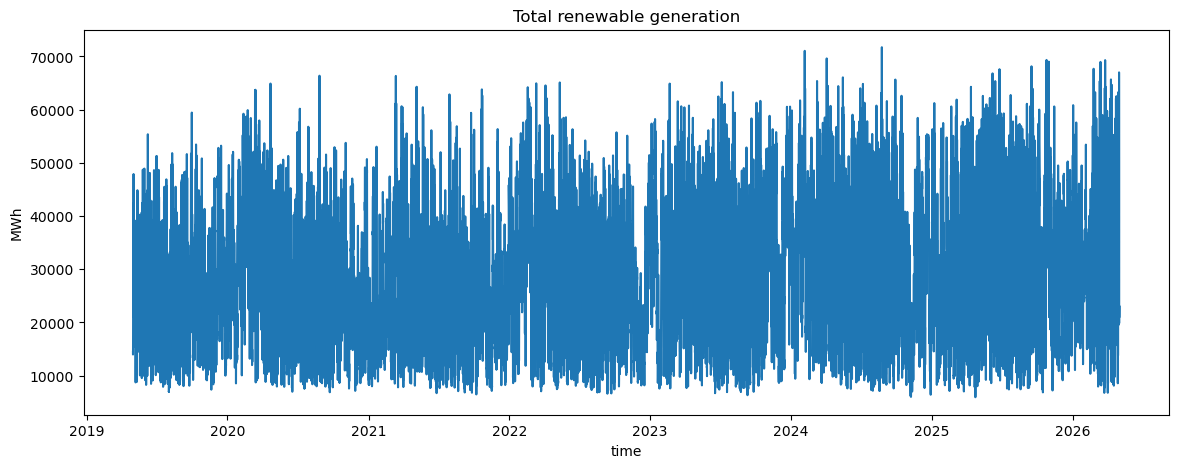

In [42]:
plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Renewables_tot'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Total renewable generation")

In [43]:
df_act_gen['Renewables_frac'] = (df_act_gen['Renewables_tot'])/(df_act_gen[generation_cols].sum(axis=1))

Text(0.5, 1.0, 'Fraction produced by renewable sources')

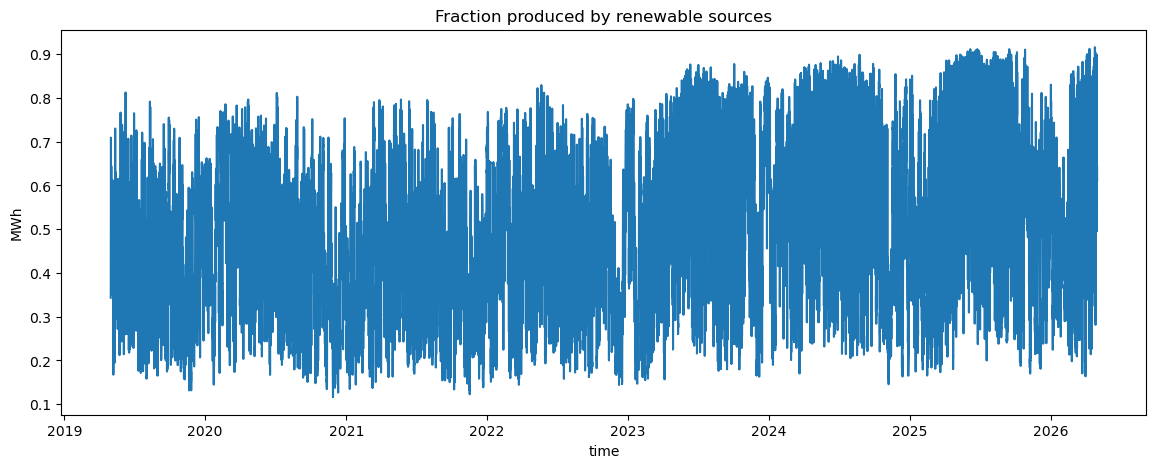

In [44]:
plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Renewables_frac'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Fraction produced by renewable sources")

Text(0.5, 1.0, 'Solar contribution to renewable sources')

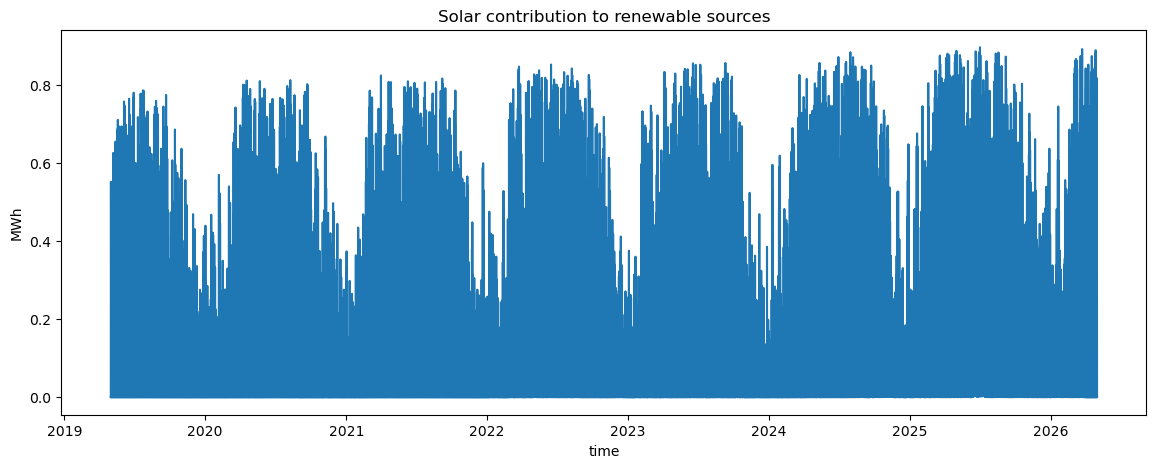

In [45]:
df_act_gen['Solar_frac'] = (df_act_gen['Photovolt'])/(df_act_gen['Renewables_tot'])

plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Solar_frac'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Solar contribution to renewable sources")

Text(0.5, 1.0, 'Wind (onshore) contribution to renewable sources')

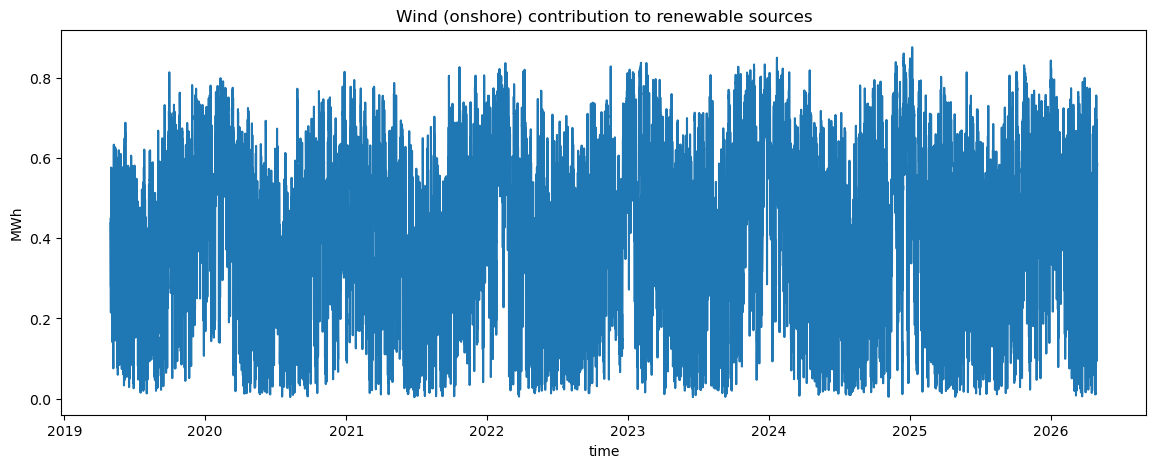

In [47]:
df_act_gen['Wind_onshore_frac'] = (df_act_gen['Wind_onshore'])/(df_act_gen['Renewables_tot'])

plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Wind_onshore_frac'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Wind (onshore) contribution to renewable sources")

Text(0.5, 1.0, 'Hydropower contribution to renewable sources')

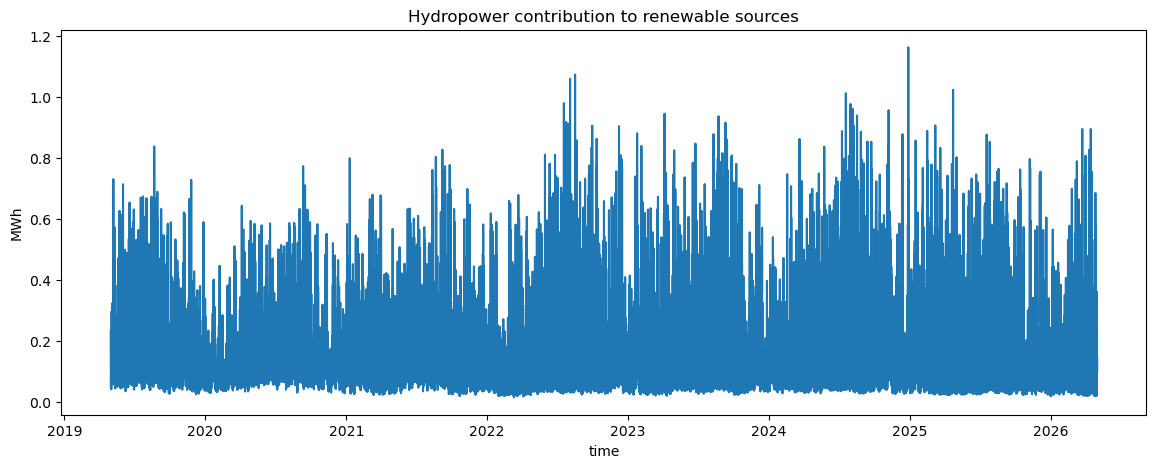

In [48]:
df_act_gen['Hydro_frac'] = (df_act_gen[['Hydro','Hydro_pump_stor']].sum(axis=1))/(df_act_gen['Renewables_tot'])

plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Hydro_frac'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Hydropower contribution to renewable sources")

In [49]:
df_act_gen['Total_gen'] = (df_act_gen[generation_cols].sum(axis=1))

Text(0.5, 1.0, 'Total generation')

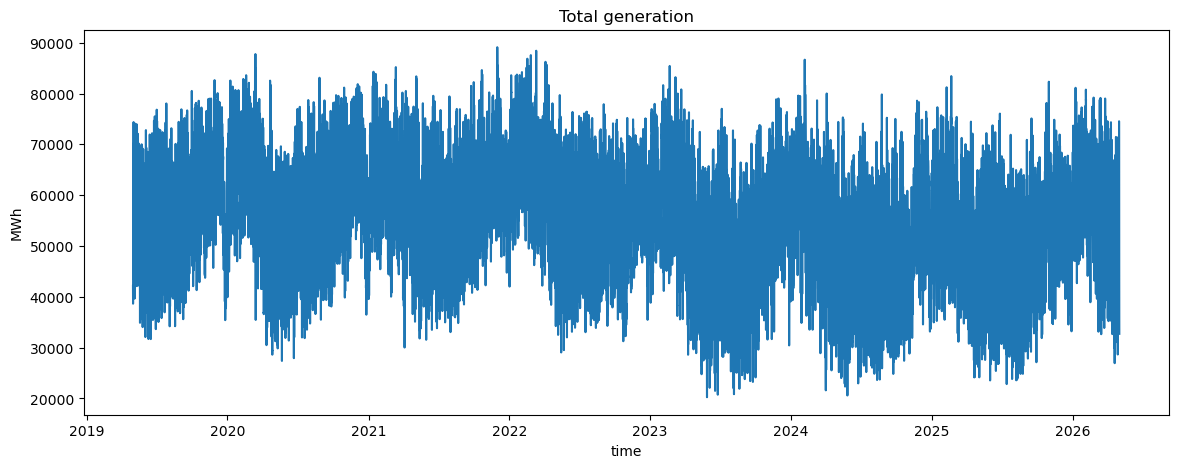

In [50]:
plt.figure(figsize=(14,5))
plt.plot(df_act_gen['Start_date'],df_act_gen['Total_gen'])
plt.ylabel("MWh")
plt.xlabel("time")
plt.title("Total generation")

In [51]:
df_act_gen.head()

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,Fossil_gas,Hydro_pump_stor,Other_conv,Renewables_tot,Renewables_frac,Solar_frac,Wind_onshore_frac,Hydro_frac,Total_gen
0,2019-05-01 00:00:00,4608.75,2123.75,1222.25,6336.0,0.0,171.50,6630.50,11257.00,3311.75,3936.25,1248.25,1470.50,14462.25,0.343155,0.0,0.438106,0.233159,42145.00
1,2019-05-01 01:00:00,4590.25,2120.50,1168.75,5916.5,0.0,174.25,6626.50,11035.00,2850.25,3594.50,1093.50,1478.50,13970.25,0.345164,0.0,0.423507,0.230060,40474.25
2,2019-05-01 02:00:00,4597.75,2052.00,1386.00,5750.0,0.0,178.25,6634.25,11090.50,2604.50,3557.00,460.25,1490.25,13964.00,0.352426,0.0,0.411773,0.179909,39622.50
3,2019-05-01 03:00:00,4593.50,2086.75,1502.75,6128.5,0.0,179.25,6637.25,11082.50,2524.00,3207.75,125.75,1483.25,14490.75,0.368047,0.0,0.422925,0.152684,39372.00
4,2019-05-01 04:00:00,4592.75,2118.50,1671.50,6520.5,0.0,181.00,6638.00,10267.25,2507.50,3109.25,178.75,1495.75,15084.25,0.385789,0.0,0.432272,0.152295,39099.75


In [52]:
df_act_gen[renewable_cols].corr()

,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren
Biomass,1.000000,-0.108439,0.125170,0.069236,-0.379682,0.599547
Hydro,-0.108439,1.000000,-0.265817,-0.282560,0.095751,-0.265541
Wind_offshore,0.125170,-0.265817,1.000000,0.622696,-0.224932,0.126832
Wind_onshore,0.069236,-0.282560,0.622696,1.000000,-0.218490,0.077248
Photovolt,-0.379682,0.095751,-0.224932,-0.218490,1.000000,-0.291607
Other_ren,0.599547,-0.265541,0.126832,0.077248,-0.291607,1.000000


Text(0, 0.5, 'Solar')

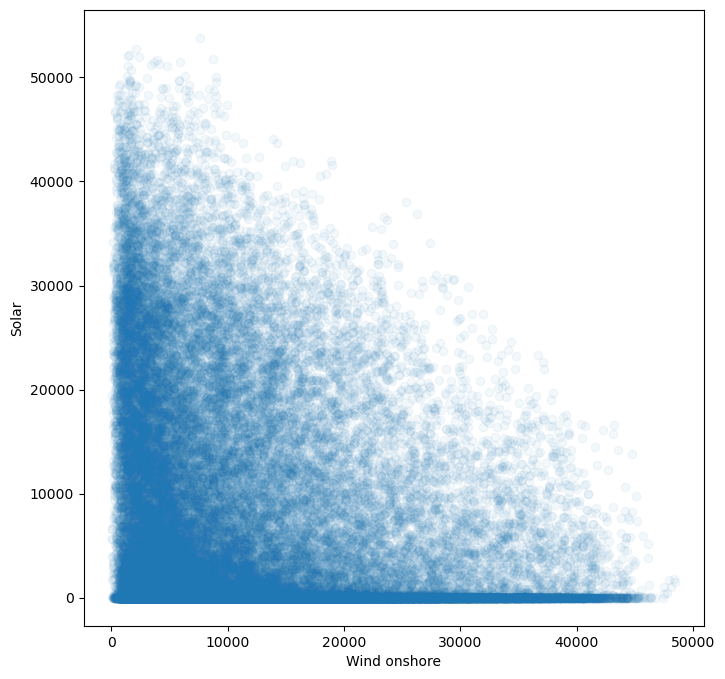

In [53]:
plt.figure(figsize=(8,8))
plt.scatter(df_act_gen['Wind_onshore'],df_act_gen['Photovolt'],alpha=0.05)
plt.xlabel('Wind onshore')
plt.ylabel('Solar')

## Actual electricity consumption data

Grid load : total electricity consumed <br>
Residual load : the electricity demand that must be fulfilled by non-renewable sources

In [54]:
df_act_consum = pd.read_csv("Actual_consumption_201905010000_202605010600_Hour.csv",sep=";")

In [55]:
df_act_consum.shape

(61374, 6)

In [56]:
df_act_consum.columns

Index(['Start date', 'End date', 'grid load [MWh] Calculated resolutions',
       'Grid load incl. hydro pumped storage [MWh] Calculated resolutions',
       'Hydro pumped storage [MWh] Calculated resolutions',
       'Residual load [MWh] Calculated resolutions'],
      dtype='str')

In [57]:
df_act_consum.head()

,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"May 1, 2019 12:00 AM","May 1, 2019 1:00 AM","44,670.75","44,784.50",113.75,"37,112.50"
1,"May 1, 2019 1:00 AM","May 1, 2019 2:00 AM","42,506.00","42,918.25",412.25,"35,420.75"
2,"May 1, 2019 2:00 AM","May 1, 2019 3:00 AM","40,888.25","41,706.50",818.25,"33,752.25"
3,"May 1, 2019 3:00 AM","May 1, 2019 4:00 AM","40,508.75","42,391.25","1,882.50","32,877.50"
4,"May 1, 2019 4:00 AM","May 1, 2019 5:00 AM","40,369.25","42,171.75","1,802.50","32,177.25"


In [58]:
cols_keep_act_con = ['Start date','grid load [MWh] Calculated resolutions',
       'Grid load incl. hydro pumped storage [MWh] Calculated resolutions',
       'Residual load [MWh] Calculated resolutions']
df_act_consum = df_act_consum[cols_keep_act_con]

df_act_consum = df_act_consum.rename(columns={'Start date':'Start_date','grid load [MWh] Calculated resolutions':'Grid_load',
       'Grid load incl. hydro pumped storage [MWh] Calculated resolutions':'Grid_load_inc_hydro_stor',
       'Residual load [MWh] Calculated resolutions':'Residual_load'})

In [59]:
df_act_consum.info()

<class 'pandas.DataFrame'>
RangeIndex: 61374 entries, 0 to 61373
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Start_date                61374 non-null  str  
 1   Grid_load                 61374 non-null  str  
 2   Grid_load_inc_hydro_stor  61374 non-null  str  
 3   Residual_load             61374 non-null  str  
dtypes: str(4)
memory usage: 4.6 MB


In [60]:
df_act_consum['Start_date'] = pd.to_datetime(df_act_consum['Start_date'],format=('%b  %d, %Y %I:%M %p'))

In [61]:
df_act_consum.columns

Index(['Start_date', 'Grid_load', 'Grid_load_inc_hydro_stor', 'Residual_load'], dtype='str')

In [62]:
not_time_col = ['Grid_load', 'Grid_load_inc_hydro_stor', 'Residual_load']


for col in not_time_col:
    df_act_consum[col] = pd.to_numeric(df_act_consum[col].str.replace(',',''),errors='coerce')

df_act_consum.info()

<class 'pandas.DataFrame'>
RangeIndex: 61374 entries, 0 to 61373
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Start_date                61374 non-null  datetime64[us]
 1   Grid_load                 61374 non-null  float64       
 2   Grid_load_inc_hydro_stor  61374 non-null  float64       
 3   Residual_load             61374 non-null  float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 1.9 MB


In [63]:
df_act_consum['Residual_load'].describe()

count    61374.000000
mean     33439.849751
std      13678.909826
min      -9664.360000
25%      24359.067500
50%      34122.000000
75%      42936.687500
max      72274.500000
Name: Residual_load, dtype: float64

In [64]:
df_act_consum['Residual_load'].lt(0).sum()

np.int64(390)

Text(0, 0.5, 'Day ahead price')

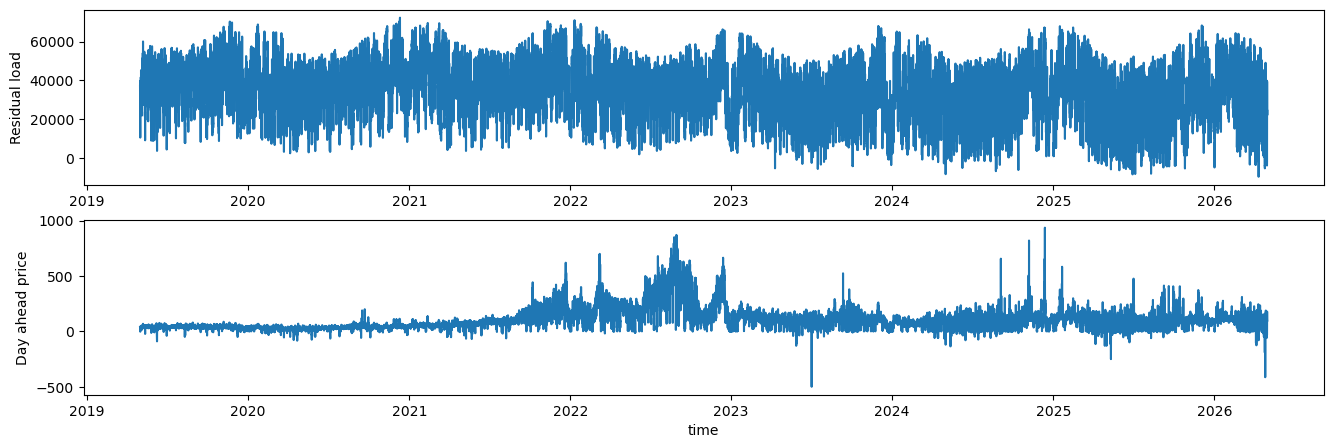

In [65]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(16,5))
ax1.plot(df_act_consum['Start_date'],df_act_consum['Residual_load'])
ax1.set_ylabel('Residual load')
ax2.plot(df_day_ahead['Start_date'],df_day_ahead['Price'])
ax2.set_xlabel('time')
ax2.set_ylabel('Day ahead price')

Text(0, 0.5, 'Day ahead price')

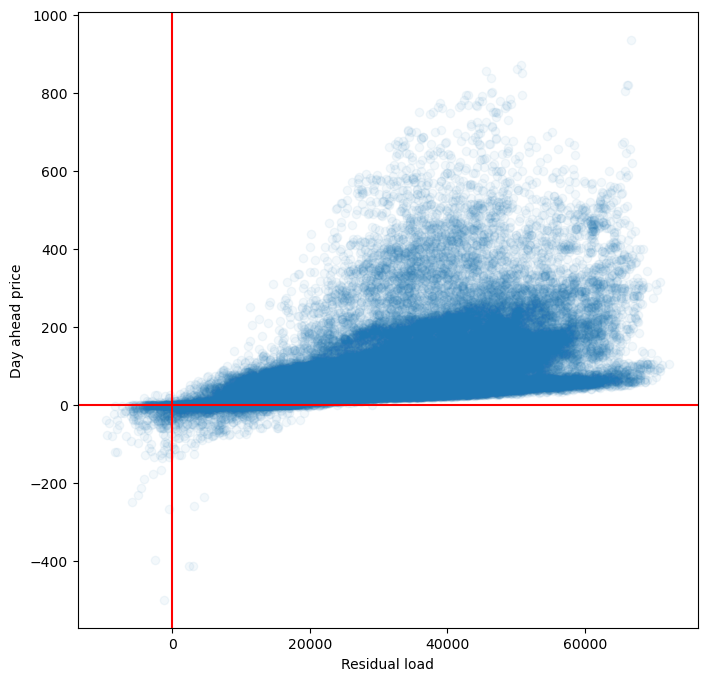

In [66]:
df_merged = pd.merge(df_day_ahead[['Start_date','Price']],df_act_consum[['Start_date','Residual_load']],on='Start_date')

plt.figure(figsize=(8,8))
plt.scatter(df_merged['Residual_load'],df_merged['Price'],alpha=0.05)
plt.axhline(0,color='r')
plt.axvline(0,color='r')
plt.xlabel('Residual load')
plt.ylabel('Day ahead price')

In [67]:
df_merged[['Residual_load','Price']].corr()

,Residual_load,Price
Residual_load,1.000000,0.424784
Price,0.424784,1.000000


Text(0.5, 1.0, 'Residual load during negative hours')

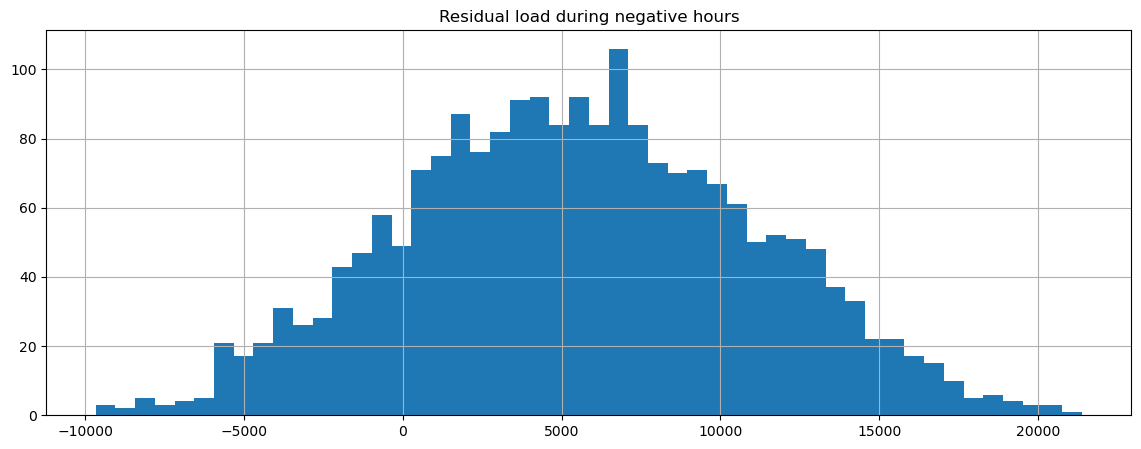

In [68]:
negative_hours = df_merged[df_merged['Price']<0]
negative_hours['Residual_load'].hist(bins=50,figsize=(14,5))
plt.title("Residual load during negative hours")

Text(0.5, 1.0, 'Residual load during all hours')

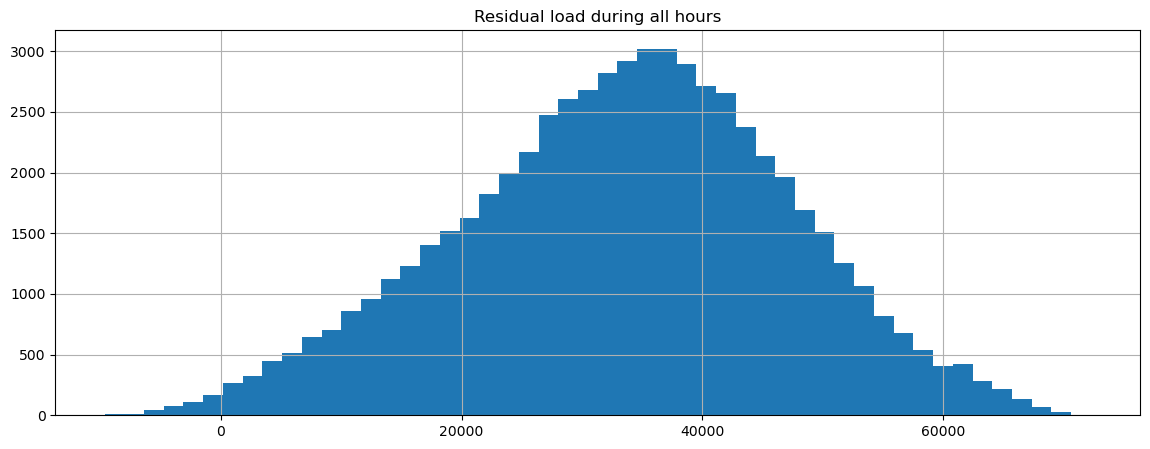

In [69]:
df_merged['Residual_load'].hist(bins=50,figsize=(14,5))
plt.title("Residual load during all hours")

Text(0, 0.5, 'Residual load')

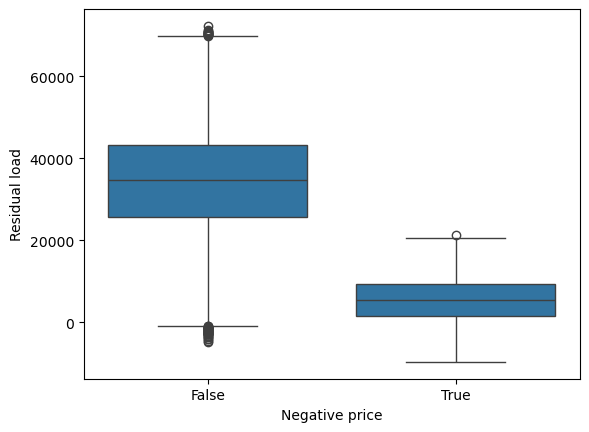

In [70]:
df_merged['Negative_price'] =(df_merged['Price']<0)

sns.boxplot(data=df_merged,x='Negative_price',y='Residual_load')
plt.xlabel('Negative price')
plt.ylabel('Residual load')

In [71]:
df_combined = df_act_gen.copy()

In [72]:
df_combined['Residuals'] = df_act_consum['Residual_load']
df_combined['Price'] = df_day_ahead['Price']
df_combined['Negative_price'] = df_day_ahead['Negative_price']

In [73]:
df_combined.describe()

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,...,Other_conv,Renewables_tot,Renewables_frac,Solar_frac,Wind_onshore_frac,Hydro_frac,Total_gen,Residuals,Price,Negative_price
count,61374,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,41653.000000,61374.000000,61374.000000,...,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000,61374.000000
mean,2022-10-30 14:05:02.140971,4292.120498,1726.014893,2909.836697,11900.637299,6391.795506,144.159945,5078.002947,9631.460833,4659.220199,...,1593.572289,27364.564838,0.495228,0.183321,0.415579,0.140127,54273.198045,33439.849751,97.389824,0.034314
min,2019-05-01 00:00:00,3085.630000,841.000000,0.000000,46.500000,0.000000,56.460000,0.000000,1823.860000,135.500000,...,530.750000,5932.250000,0.115859,0.000000,0.003255,0.014249,20243.500000,-9664.360000,-500.000000,0.000000
25%,2021-01-29 06:15:00,4060.750000,1402.000000,1103.250000,4478.250000,3.250000,113.000000,2995.500000,6711.562500,2116.750000,...,1411.000000,16719.872500,0.347819,0.000165,0.248198,0.057910,45782.500000,24359.067500,38.970000,0.000000
50%,2022-10-30 13:30:00,4311.750000,1691.500000,2685.750000,9225.250000,194.750000,134.000000,6264.750000,10187.250000,3821.375000,...,1576.250000,25739.750000,0.485848,0.009868,0.429320,0.099622,54537.750000,34122.000000,79.960000,0.000000
75%,2024-07-30 21:45:00,4542.000000,2016.000000,4614.750000,17108.352500,10060.375000,173.250000,7741.500000,12439.437500,6389.000000,...,1792.500000,36447.750000,0.632748,0.349641,0.586472,0.177789,62836.562500,42936.687500,118.520000,0.000000
max,2026-05-01 05:00:00,5271.250000,3082.000000,8448.340000,48499.500000,53817.020000,244.250000,9367.500000,17173.250000,16393.500000,...,2669.500000,71742.000000,0.916046,0.896661,0.877430,1.162341,89113.750000,72274.500000,936.280000,1.000000
std,NaN,333.994457,412.104111,1984.414873,9434.170286,9970.045538,38.822857,2919.835669,3567.570733,3223.870650,...,270.018643,12727.734677,0.180930,0.251393,0.207495,0.122039,11682.262393,13678.909826,93.597457,0.182036


In [74]:
df_combined.columns

Index(['Start_date', 'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt', 'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv', 'Renewables_tot',
       'Renewables_frac', 'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac',
       'Total_gen', 'Residuals', 'Price', 'Negative_price'],
      dtype='str')

In [75]:
df_combined.head()

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,...,Other_conv,Renewables_tot,Renewables_frac,Solar_frac,Wind_onshore_frac,Hydro_frac,Total_gen,Residuals,Price,Negative_price
0,2019-05-01 00:00:00,4608.75,2123.75,1222.25,6336.0,0.0,171.50,6630.50,11257.00,3311.75,...,1470.50,14462.25,0.343155,0.0,0.438106,0.233159,42145.00,37112.50,38.00,0
1,2019-05-01 01:00:00,4590.25,2120.50,1168.75,5916.5,0.0,174.25,6626.50,11035.00,2850.25,...,1478.50,13970.25,0.345164,0.0,0.423507,0.230060,40474.25,35420.75,35.20,0
2,2019-05-01 02:00:00,4597.75,2052.00,1386.00,5750.0,0.0,178.25,6634.25,11090.50,2604.50,...,1490.25,13964.00,0.352426,0.0,0.411773,0.179909,39622.50,33752.25,32.64,0
3,2019-05-01 03:00:00,4593.50,2086.75,1502.75,6128.5,0.0,179.25,6637.25,11082.50,2524.00,...,1483.25,14490.75,0.368047,0.0,0.422925,0.152684,39372.00,32877.50,31.16,0
4,2019-05-01 04:00:00,4592.75,2118.50,1671.50,6520.5,0.0,181.00,6638.00,10267.25,2507.50,...,1495.75,15084.25,0.385789,0.0,0.432272,0.152295,39099.75,32177.25,29.56,0


In [76]:
df_combined.to_csv("Combined_smard_data.csv",index=False)